# Esercizio 1 - Lezione 4
## Modello sequenziale per la regressione

### Caricamento dati

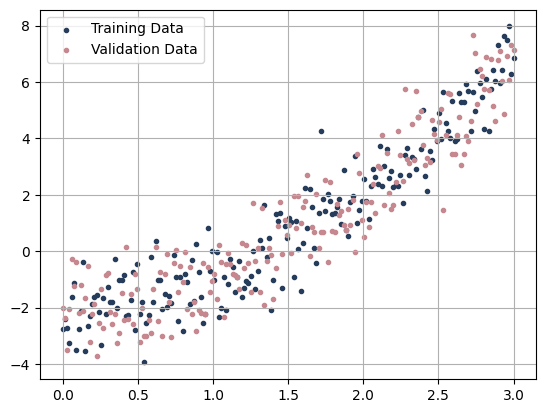

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('data.dat')

x_tr = data[:,0]
y_tr = data[:,1]
x_val = data[:,2]
y_val = data[:,3]

plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Modello lineare di baseline

In [3]:
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(1))

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
               loss=tf.keras.losses.MeanSquaredError)

history = model.fit(x_tr, y_tr, epochs=500,
          batch_size = x_tr.shape[0],
          validation_data = (x_val, y_val))

2026-03-26 19:17:00.500097: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2026-03-26 19:17:00.500140: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-26 19:17:00.500153: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-26 19:17:00.500201: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-26 19:17:00.500224: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - loss: 27.7868

2026-03-26 19:17:00.829556: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - loss: 27.7868 - val_loss: 24.4238
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 24.6403 - val_loss: 21.7559
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 21.9489 - val_loss: 19.4746
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 19.6459 - val_loss: 17.5232
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 17.6745 - val_loss: 15.8534
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 15.9861 - val_loss: 14.4238
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 14.5393 - val_loss: 13.1992
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 13.2987 - val_loss: 12.1494
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 12.2341 - val_loss: 11.2489
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 11.3199 - val_loss: 10.4756
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 10.5340 - val_loss: 9.8110
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 9.857

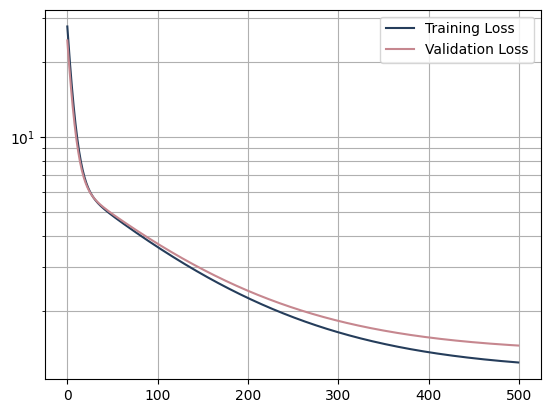

In [4]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


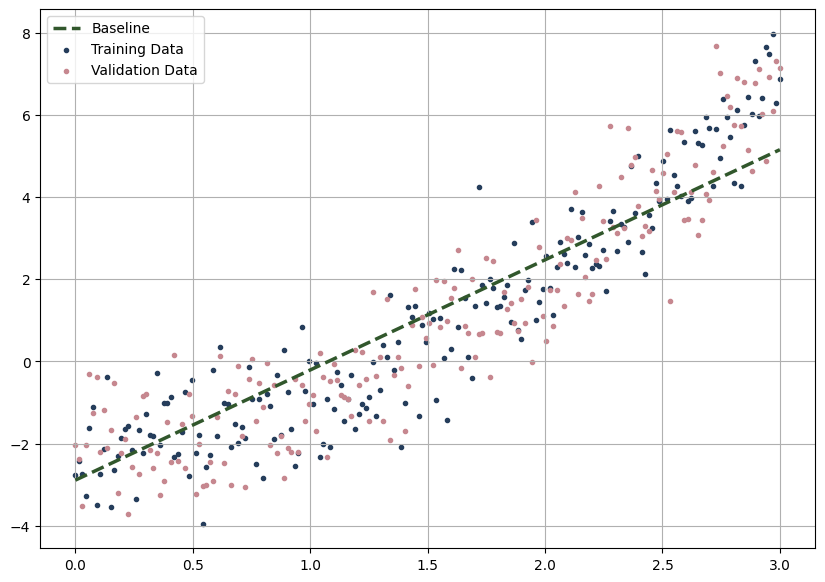

In [5]:
plt.figure(figsize=(10,7))
plt.plot(x_tr, model.predict(x_tr), '--',label='Baseline', color="#31572C", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', c='#253D5B', marker='.')
plt.scatter(x_val, y_val, label='Validation Data', c='#C6878F', marker='.')
plt.grid()
plt.legend()

### Fully connected deep neural network con attivazione leaky-relu

In [6]:
model2 = tf.keras.models.Sequential()

model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(10, activation='leaky_relu'))
model2.add(tf.keras.layers.Dense(1, activation='linear'))

model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.01), loss=tf.keras.losses.MSE)

history = model2.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=500, 
                     batch_size=x_tr.shape[0])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 7.8416 - val_loss: 7.3642
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 7.3657 - val_loss: 6.9509
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 6.9420 - val_loss: 6.5386
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 6.5184 - val_loss: 6.1542
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 6.1220 - val_loss: 5.8017
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.7574 - val_loss: 5.4739
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.4167 - val_loss: 5.1924
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 5.1222 - val_loss: 4.9492
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 4.8662 - val_loss: 4.7591
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.6648 - val_loss: 4.6077
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.5039 - val_loss: 4.4803
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 4.3689 - val_l

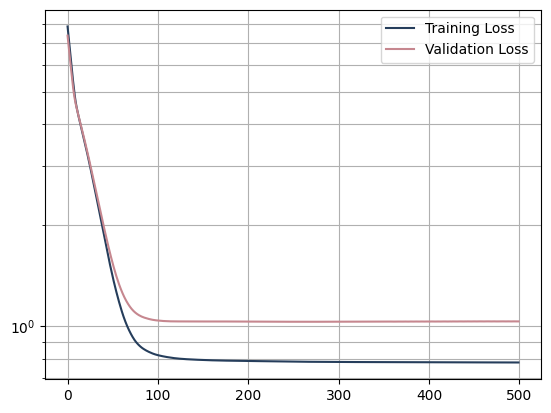

In [7]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


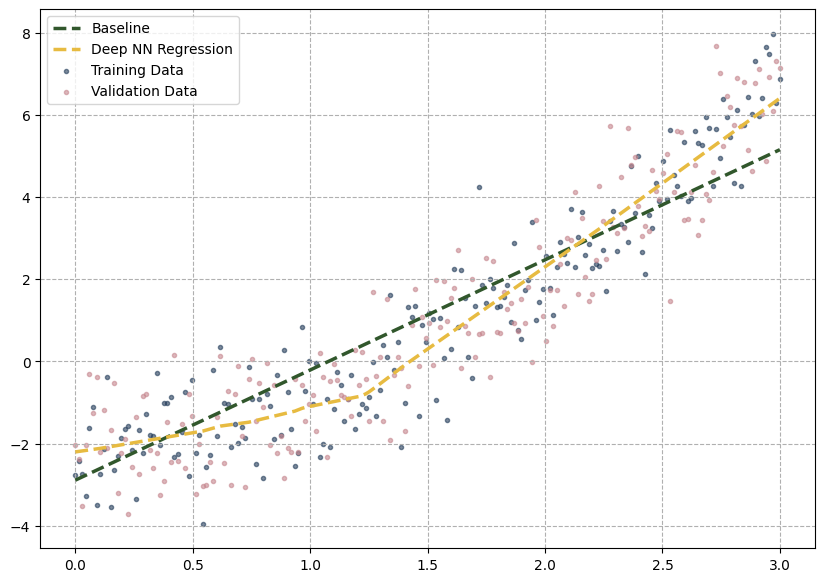

In [8]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model2.predict(x_val), '--', label='Deep NN Regression', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()

### Fully connected deep neural network con relu

In [9]:

model3 = tf.keras.models.Sequential()

model3.add(tf.keras.layers.Input(shape=(1,)))
model3.add(tf.keras.layers.Dense(10, activation='relu'))
model3.add(tf.keras.layers.Dense(10, activation='relu'))
model3.add(tf.keras.layers.Dense(10, activation='relu'))
model3.add(tf.keras.layers.Dense(1, activation='linear'))

model3.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.001), loss=tf.keras.losses.MSE)

history = model3.fit(x_tr, y_tr, 
                     validation_data=(x_val, y_val), 
                     epochs=500, 
                     batch_size=x_tr.shape[0])

Epoch 1/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - loss: 4.6556 - val_loss: 4.7853
Epoch 2/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 4.6031 - val_loss: 4.7348
Epoch 3/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 4.5548 - val_loss: 4.6883
Epoch 4/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4.5104 - val_loss: 4.6454
Epoch 5/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4.4696 - val_loss: 4.6059
Epoch 6/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 4.4319 - val_loss: 4.5692
Epoch 7/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 4.3971 - val_loss: 4.5353
Epoch 8/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.3649 - val_loss: 4.5038
Epoch 9/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.3350 - val_loss: 4.4745
Epoch 10/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.3072 - val_loss: 4.4472
Epoch 11/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 4.2814 - val_loss: 4.4218
Epoch 12/500
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 4.2574 - val_l

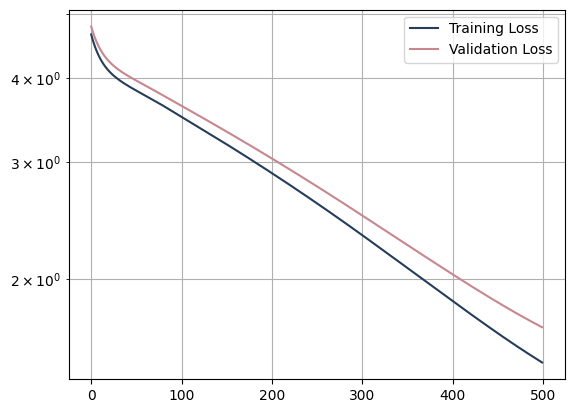

In [10]:
plt.plot(history.epoch, history.history['loss'], label='Training Loss', color='#253D5B')
plt.plot(history.epoch, history.history['val_loss'], label='Validation Loss', color='#C6878F')
plt.legend()
plt.semilogy()
plt.grid('both', 'both')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  


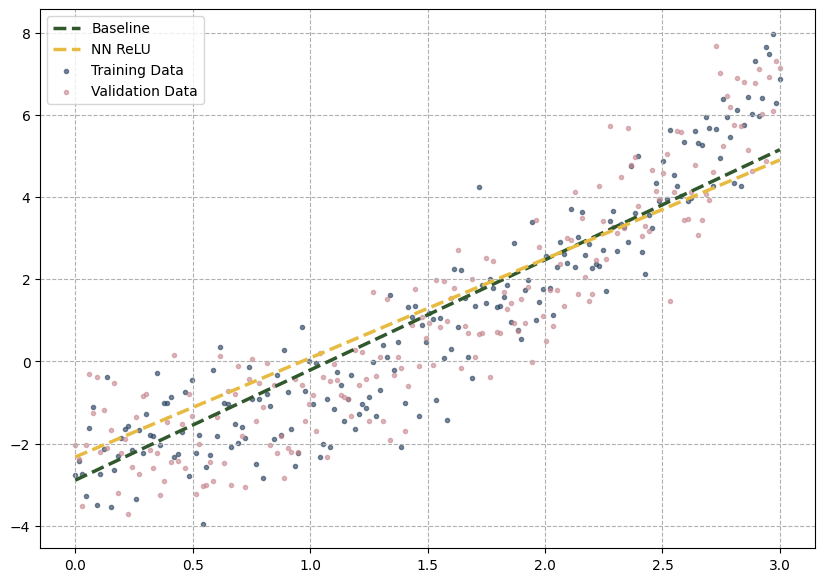

In [11]:
plt.figure(figsize=(10,7))
plt.grid(linestyle='--')
plt.plot(x_val, model.predict(x_val), '--', label='Baseline', color="#31572C", linewidth=2.5)
plt.plot(x_val, model3.predict(x_val), '--', label='NN ReLU', color="#E7BB41", linewidth=2.5)
plt.scatter(x_tr, y_tr, label='Training Data', marker='.', c='#253D5B', alpha=0.6)
plt.scatter(x_val, y_val, label='Validation Data', marker='.', c='#C6878F', alpha=0.6)
plt.legend()